# Buổi 1 – Lab: Phân tích thống kê bộ KPI mạng lưới
### Khóa Data Scientist – Module 1

**Mục tiêu:** xây dựng hồ sơ thống kê (statistical profile) cho các KPI mạng, phát hiện outlier, phân tích alarm và viết kết luận vận hành.

**Đầu ra:** notebook chạy được từ đầu đến cuối + các bảng/nhận xét phục vụ báo cáo `reports/kpi_statistical_profile.md`.

**Cấu trúc notebook (theo gợi ý slide 21):**
1. Import & cấu hình
2. Sinh synthetic data (mô phỏng KPI mạng)
3. Kiểm tra schema & Data Quality (Phần A)
4. Thống kê mô tả toàn mạng (Phần B)
5. Phân tích theo region (Phần B)
6. Percentile, histogram & boxplot (Phần C)
7. Phát hiện outlier – IQR & z-score (Phần D)
8. Phân tích alarm & so sánh Poisson (Phần E)
9. Kết luận vận hành (Phần F)

> Dữ liệu dùng trong lab là **synthetic (mô phỏng)** để đúng yêu cầu chương trình.


## 1. Import thư viện và cấu hình

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)
print("Setup done.")

Setup done.


## 2. Sinh synthetic data mô phỏng KPI mạng

**Grain của bảng:** `một trạm (site) – một ngày – một KPI record` (mỗi dòng = 1 site × 1 ngày).

Ta mô phỏng đặc trưng của từng KPI đúng bản chất trong bài giảng:

| KPI | Bản chất | Cách mô phỏng |
|---|---|---|
| CSSR (%) | Tỷ lệ, gần 100, lệch trái | 100 − Gamma nhỏ |
| Throughput (Mbps) | Liên tục, right-skew, đuôi dài | Lognormal |
| PRB utilization (%) | Tỷ lệ 0–100 | Beta scaled |
| Drop rate (%) | Nhỏ, right-skew | Gamma |
| Latency (ms) | Liên tục, đuôi dài (P95/P99 quan trọng) | Lognormal |
| Alarm/giờ | Số đếm rời rạc | Poisson |

Thêm chủ đích: **1 region "xấu"** (Region_A: latency & drop cao hơn), một ít **missing**, **duplicate**, và vài **outlier / lỗi data-quality** (latency âm, CSSR > 100) để thực hành Phần A & D.


In [2]:
# ---- Tham số mô phỏng ----
N_SITES = 60
N_DAYS = 45                       # ~6-7 tuần để tổng hợp theo tuần
REGIONS = ["Region_A", "Region_B", "Region_C", "Region_D"]

dates = pd.date_range("2025-01-01", periods=N_DAYS, freq="D")
sites = [f"SITE_{i:03d}" for i in range(N_SITES)]

# Gán mỗi site vào 1 region cố định
site_region = {s: REGIONS[i % len(REGIONS)] for i, s in enumerate(sites)}

# Region_A là region "có vấn đề": latency & drop rate cao hơn
region_latency_mult = {"Region_A": 1.6, "Region_B": 1.0, "Region_C": 1.0, "Region_D": 1.05}
region_drop_add     = {"Region_A": 0.8, "Region_B": 0.0, "Region_C": 0.0, "Region_D": 0.1}

rows = []
for d in dates:
    # yếu tố giờ cao điểm theo ngày (giả lập biến động)
    day_load = 1.0 + 0.15 * np.sin(d.dayofyear / 3.0)
    for s in sites:
        r = site_region[s]
        cssr = 100 - rng.gamma(shape=2.0, scale=0.6)                 # ~98-99%
        throughput = rng.lognormal(mean=3.4, sigma=0.45) * day_load   # Mbps, right-skew
        prb = np.clip(rng.beta(2.2, 2.0) * 100 * day_load, 0, 100)    # %
        drop = rng.gamma(shape=1.5, scale=0.4) + region_drop_add[r]   # %
        latency = rng.lognormal(mean=3.0, sigma=0.4) * region_latency_mult[r]  # ms
        alarms = rng.poisson(lam=3.0 * (region_latency_mult[r]))      # số alarm/giờ (đại diện)
        rows.append([d, s, r, cssr, throughput, prb, drop, latency, alarms])

df = pd.DataFrame(rows, columns=[
    "date", "site_id", "region", "cssr_pct", "throughput_mbps",
    "prb_util_pct", "drop_rate_pct", "latency_ms", "alarms_per_hour"
])
print("Base shape:", df.shape)
df.head()

Base shape: (2700, 9)


,date,site_id,region,cssr_pct,throughput_mbps,prb_util_pct,drop_rate_pct,latency_ms,alarms_per_hour
0,2025-01-01,SITE_000,Region_A,98.745,44.063,91.984,1.143,22.846,7
1,2025-01-01,SITE_001,Region_B,98.154,28.926,44.400,0.330,23.247,4
2,2025-01-01,SITE_002,Region_C,99.507,52.245,71.180,0.867,12.573,4
3,2025-01-01,SITE_003,Region_D,98.162,42.667,44.885,0.442,16.334,1
4,2025-01-01,SITE_004,Region_A,99.532,14.741,38.013,1.700,26.711,4


In [3]:
# ---- Chủ đích bơm các vấn đề dữ liệu để thực hành Phần A & D ----
df = df.copy()

# (a) Missing values ngẫu nhiên ở throughput & latency
miss_idx = rng.choice(df.index, size=25, replace=False)
df.loc[miss_idx[:13], "throughput_mbps"] = np.nan
df.loc[miss_idx[13:], "latency_ms"] = np.nan

# (b) Duplicate rows (lỗi ingest)
dups = df.sample(8, random_state=1)
df = pd.concat([df, dups], ignore_index=True)

# (c) Lỗi data-quality: latency âm, CSSR > 100 (không hợp lệ về nghiệp vụ)
dq_idx = rng.choice(df.index, size=6, replace=False)
df.loc[dq_idx[:3], "latency_ms"] = -abs(df.loc[dq_idx[:3], "latency_ms"])
df.loc[dq_idx[3:], "cssr_pct"] = 100 + rng.uniform(0.5, 3, size=3)

# (d) Outlier "tín hiệu vận hành": vài spike latency & alarm rất cao (giờ cao điểm)
op_idx = rng.choice(df.index, size=10, replace=False)
df.loc[op_idx, "latency_ms"] = df.loc[op_idx, "latency_ms"].abs() * rng.uniform(3, 6, size=10)
df.loc[op_idx, "alarms_per_hour"] = df.loc[op_idx, "alarms_per_hour"] + rng.integers(15, 30, size=10)

df = df.sample(frac=1, random_state=7).reset_index(drop=True)
print("Final shape (sau khi bơm vấn đề):", df.shape)
df.head()

Final shape (sau khi bơm vấn đề): (2708, 9)


,date,site_id,region,cssr_pct,throughput_mbps,prb_util_pct,drop_rate_pct,latency_ms,alarms_per_hour
0,2025-02-12,SITE_040,Region_A,99.636,40.076,20.631,0.898,18.191,7
1,2025-01-17,SITE_047,Region_D,97.546,25.016,54.668,0.616,16.529,5
2,2025-01-13,SITE_050,Region_C,99.653,21.147,46.740,0.510,16.917,4
3,2025-01-22,SITE_037,Region_B,98.234,33.264,72.108,1.540,13.783,4
4,2025-01-08,SITE_003,Region_D,99.374,36.770,24.168,0.319,19.358,1


## 3. Phần A – Kiểm tra dữ liệu (schema & Data Quality)

Theo yêu cầu Phần A:
1. Số dòng, số cột, kiểu dữ liệu
2. Xác định **grain** của bảng
3. Missing value & duplicate (mức cơ bản)
4. Xác định các KPI chính cần phân tích


In [4]:
print("Số dòng x số cột:", df.shape)
print("\n--- Kiểu dữ liệu ---")
print(df.dtypes)
print("\n--- Số lượng region / site / ngày ---")
print("Regions:", df["region"].nunique(), "| Sites:", df["site_id"].nunique(), "| Days:", df["date"].nunique())

Số dòng x số cột: (2708, 9)

--- Kiểu dữ liệu ---
date               datetime64[ns]
site_id                    object
region                     object
cssr_pct                  float64
throughput_mbps           float64
prb_util_pct              float64
drop_rate_pct             float64
latency_ms                float64
alarms_per_hour             int64
dtype: object

--- Số lượng region / site / ngày ---
Regions: 4 | Sites: 60 | Days: 45


In [5]:
# Kiểm tra grain: (site_id, date) có duy nhất không?
grain_dup = df.duplicated(subset=["site_id", "date"]).sum()
print(f"Số cặp (site_id, date) bị lặp: {grain_dup}")
print("=> Grain kỳ vọng: 1 dòng = 1 site x 1 ngày. Nếu > 0 là có duplicate cần xử lý.")

Số cặp (site_id, date) bị lặp: 8
=> Grain kỳ vọng: 1 dòng = 1 site x 1 ngày. Nếu > 0 là có duplicate cần xử lý.


In [6]:
# Missing values
miss = df.isna().sum()
miss_pct = (df.isna().mean() * 100).round(2)
missing_report = pd.DataFrame({"n_missing": miss, "pct_missing": miss_pct})
missing_report[missing_report.n_missing > 0]

,n_missing,pct_missing
throughput_mbps,13,0.480
latency_ms,13,0.480


In [7]:
# Duplicate rows hoàn toàn
n_full_dup = df.duplicated().sum()
print("Số dòng trùng hoàn toàn:", n_full_dup)

# Lỗi data-quality theo luật nghiệp vụ
dq_neg_latency = (df["latency_ms"] < 0).sum()
dq_cssr_over   = (df["cssr_pct"] > 100).sum()
dq_prb_range   = ((df["prb_util_pct"] < 0) | (df["prb_util_pct"] > 100)).sum()
print(f"latency âm: {dq_neg_latency} | CSSR > 100%: {dq_cssr_over} | PRB ngoài [0,100]: {dq_prb_range}")

Số dòng trùng hoàn toàn: 8
latency âm: 3 | CSSR > 100%: 3 | PRB ngoài [0,100]: 0


In [8]:
# KPI chính cần phân tích
KPI_COLS = ["cssr_pct", "throughput_mbps", "prb_util_pct", "drop_rate_pct", "latency_ms"]
COUNT_COL = "alarms_per_hour"
print("KPI liên tục/tỷ lệ:", KPI_COLS)
print("KPI số đếm:", COUNT_COL)

KPI liên tục/tỷ lệ: ['cssr_pct', 'throughput_mbps', 'prb_util_pct', 'drop_rate_pct', 'latency_ms']
KPI số đếm: alarms_per_hour


### 📝 Nhận xét Phần A (điền của học viên)
- Grain: 1 dòng = 1 site × 1 ngày; đã phát hiện ... cặp trùng grain.
- Missing tập trung ở throughput/latency (~ ...%).
- Lỗi DQ: latency âm và CSSR>100 là **lỗi dữ liệu**, cần loại/sửa trước khi tính thống kê.


In [9]:
# ---- Làm sạch tối thiểu để phân tích (giữ bản gốc để so sánh) ----
df_clean = df.drop_duplicates().copy()
# loại lỗi DQ rõ ràng (không hợp lệ nghiệp vụ)
df_clean = df_clean[(df_clean["latency_ms"].isna()) | (df_clean["latency_ms"] >= 0)]
df_clean = df_clean[(df_clean["cssr_pct"] <= 100)]
print("Sau làm sạch:", df_clean.shape)

Sau làm sạch: (2694, 9)


## 4. Phần B – Thống kê mô tả toàn mạng

Yêu cầu: mean, median, std, IQR, CV và percentile (5,25,50,75,90,95,99).


In [10]:
def describe_kpi(series):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    mean = s.mean()
    out = {
        "mean": mean, "median": s.median(), "std": s.std(ddof=1),
        "IQR": q3 - q1, "CV": s.std(ddof=1) / mean if mean != 0 else np.nan,
        "P5": s.quantile(0.05), "P25": q1, "P50": s.quantile(0.50),
        "P75": q3, "P90": s.quantile(0.90), "P95": s.quantile(0.95),
        "P99": s.quantile(0.99),
    }
    return pd.Series(out)

profile = df_clean[KPI_COLS].apply(describe_kpi).T
profile

,mean,median,std,IQR,CV,P5,P25,P50,P75,P90,P95,P99
cssr_pct,98.818,99.009,0.841,1.039,0.009,97.242,98.397,99.009,99.437,99.690,99.774,99.901
throughput_mbps,34.654,31.032,17.545,19.289,0.506,14.152,22.766,31.032,42.055,56.374,68.249,94.841
prb_util_pct,54.018,53.604,23.104,35.669,0.428,16.637,36.023,53.604,71.692,85.821,91.659,100.000
drop_rate_pct,0.856,0.743,0.612,0.822,0.716,0.121,0.368,0.743,1.190,1.647,1.975,2.762
latency_ms,25.370,22.302,14.578,13.616,0.575,10.984,16.801,22.302,30.417,40.029,47.820,71.998


In [11]:
# CV cho biết KPI nào biến động mạnh (đã chuẩn hóa theo mean)
cv_rank = profile["CV"].sort_values(ascending=False)
print("Xếp hạng biến động (CV cao = biến động mạnh):")
print(cv_rank)

Xếp hạng biến động (CV cao = biến động mạnh):
drop_rate_pct     0.716
latency_ms        0.575
throughput_mbps   0.506
prb_util_pct      0.428
cssr_pct          0.009
Name: CV, dtype: float64


### 📝 Nhận xét Phần B (điền của học viên)
- KPI ổn định (CV thấp): ...
- KPI biến động mạnh (CV cao): ...
- Với latency, khoảng cách P50 → P95/P99 lớn cho thấy đuôi dài.


### 5. Phần B (tiếp) – So sánh KPI theo region

In [12]:
region_stats = df_clean.groupby("region")[KPI_COLS].agg(["mean", "median", "std"])
region_stats

cssr_pct              throughput_mbps               prb_util_pct  \
             mean median   std            mean median    std         mean   
region                                                                      
Region_A   98.790 98.998 0.868          35.048 32.018 16.552       53.558   
Region_B   98.823 99.019 0.824          34.996 31.466 17.356       54.111   
Region_C   98.814 98.988 0.829          34.392 30.335 19.065       54.035   
Region_D   98.843 99.050 0.844          34.180 30.316 17.135       54.366   

                       drop_rate_pct              latency_ms                
         median    std          mean median   std       mean median    std  
region                                                                      
Region_A 52.822 23.645         1.413  1.263 0.535     35.482 32.028 19.858  
Region_B 53.840 23.425         0.638  0.507 0.488     21.422 19.729  9.238  
Region_C 53.944 22.771         0.661  0.504 0.544     21.758 20.141  9.758  
Region_D 53.823 22.606         0.712  0.574 0.514     22.873 20.951 11.846

In [13]:
# Latency P95 theo region – dấu hiệu region cần chú ý
p95_by_region = df_clean.groupby("region")["latency_ms"].quantile(0.95).sort_values(ascending=False)
print("Latency P95 theo region:")
print(p95_by_region)

Latency P95 theo region:
region
Region_A   65.542
Region_D   39.493
Region_B   38.823
Region_C   38.484
Name: latency_ms, dtype: float64


## 6. Phần C – Trực quan hóa

Mỗi biểu đồ đi kèm 1 nhận xét dựa trên dữ liệu (không chỉ mô tả biểu đồ có gì).


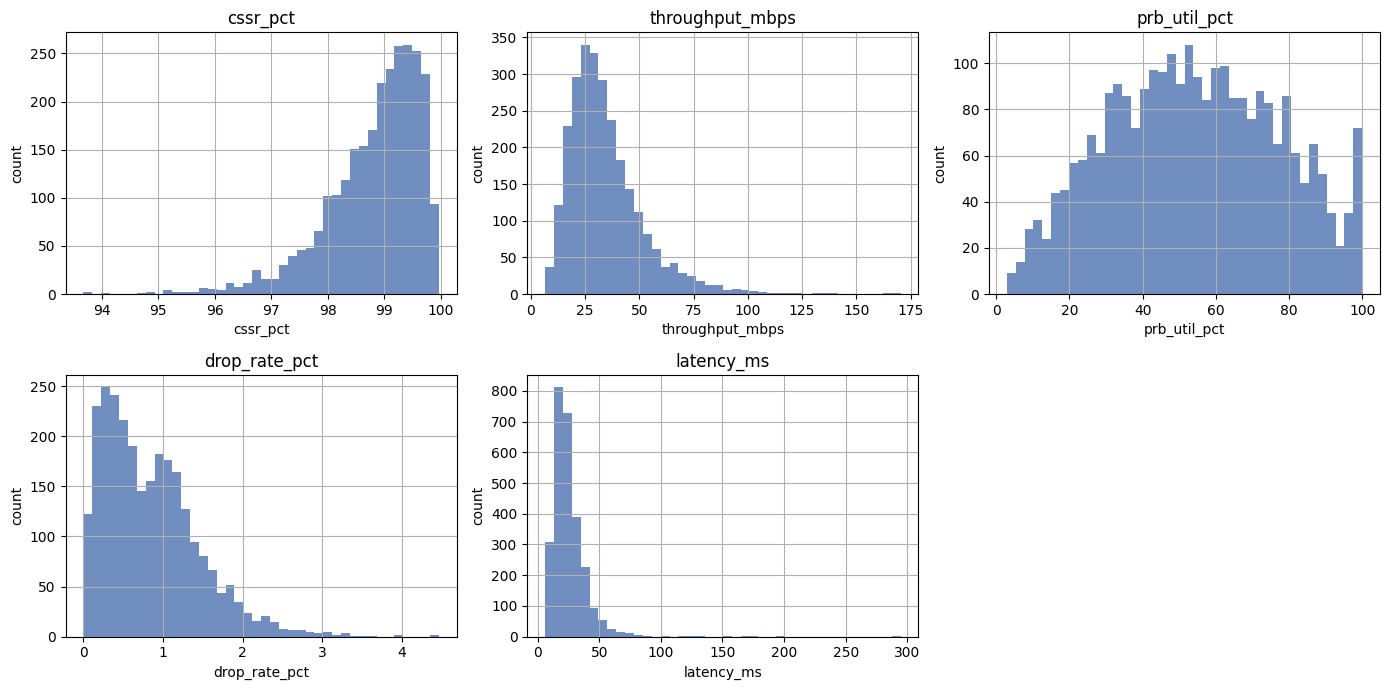

In [14]:
# Histogram cho các KPI chính
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), KPI_COLS):
    df_clean[col].dropna().hist(bins=40, ax=ax, color="#4C72B0", alpha=0.8)
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel("count")
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

/tmp/ipykernel_2525/3395486659.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=REGIONS, showfliers=True)


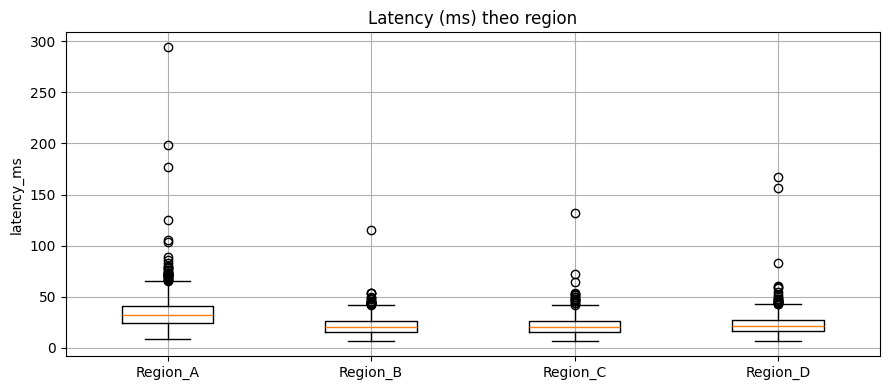

In [15]:
# Boxplot latency theo region (so sánh phân phối giữa các region)
fig, ax = plt.subplots(figsize=(9, 4))
data = [df_clean.loc[df_clean.region == r, "latency_ms"].dropna() for r in REGIONS]
ax.boxplot(data, labels=REGIONS, showfliers=True)
ax.set_title("Latency (ms) theo region"); ax.set_ylabel("latency_ms")
plt.tight_layout(); plt.show()

### 📝 Nhận xét Phần C (điền của học viên)
- Histogram latency/throughput lệch phải (right-skew), xác nhận nên dùng median + percentile.
- Boxplot: Region_A có median & whisker trên cao hơn, nhiều outlier phía trên.


## 7. Phần D – Phát hiện outlier (IQR & z-score)

Công thức (slide 7, 8, 22, 23):
- `IQR = Q3 − Q1`, `Lower = Q1 − 1.5·IQR`, `Upper = Q3 + 1.5·IQR`
- `z = (x − mean) / s`, gắn cờ `|z| > 3`


In [16]:
def iqr_outliers(series, k=1.5):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    mask = (series < lower) | (series > upper)
    return mask.fillna(False), lower, upper

def zscore_outliers(series, thr=3.0):
    m, sd = series.mean(), series.std(ddof=1)
    z = (series - m) / sd
    return (z.abs() > thr).fillna(False), z

col = "latency_ms"
iqr_mask, lo, up = iqr_outliers(df_clean[col])
z_mask, z = zscore_outliers(df_clean[col])
print(f"[{col}] IQR bounds: ({lo:.2f}, {up:.2f})")
print(f"Outlier theo IQR: {iqr_mask.sum()} | theo z-score(|z|>3): {z_mask.sum()}")
print(f"Trùng nhau (cả hai phương pháp): {(iqr_mask & z_mask).sum()}")

[latency_ms] IQR bounds: (-3.62, 50.84)
Outlier theo IQR: 111 | theo z-score(|z|>3): 34
Trùng nhau (cả hai phương pháp): 34


In [17]:
# So sánh outlier toàn mạng vs theo từng region (slide 24)
def region_iqr_outliers(g):
    mask, _, _ = iqr_outliers(g["latency_ms"])
    return mask.sum()

global_out = iqr_mask.sum()
per_region_out = df_clean.groupby("region").apply(region_iqr_outliers)
print("Outlier latency toàn mạng (IQR):", global_out)
print("\nOutlier latency tính TRONG từng region:")
print(per_region_out)

Outlier latency toàn mạng (IQR): 111

Outlier latency tính TRONG từng region:
region
Region_A    34
Region_B    22
Region_C    17
Region_D    22
dtype: int64


/tmp/ipykernel_2525/466591297.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_region_out = df_clean.groupby("region").apply(region_iqr_outliers)


In [18]:
# Bảng phân loại outlier: lỗi dữ liệu vs tín hiệu vận hành
out_view = df_clean.loc[iqr_mask, ["date", "site_id", "region", "latency_ms", "alarms_per_hour", "drop_rate_pct"]]
out_view = out_view.sort_values("latency_ms", ascending=False)
out_view.head(15)

,date,site_id,region,latency_ms,alarms_per_hour,drop_rate_pct
66,2025-01-13,SITE_012,Region_A,294.500,28,1.340
1951,2025-02-08,SITE_012,Region_A,198.673,26,1.015
578,2025-01-11,SITE_040,Region_A,176.581,23,0.966
269,2025-01-03,SITE_027,Region_D,167.104,27,0.326
1812,2025-01-30,SITE_035,Region_D,156.213,31,1.839
643,2025-01-19,SITE_002,Region_C,132.229,26,0.992
2216,2025-02-08,SITE_036,Region_A,125.486,33,1.147
1249,2025-01-25,SITE_029,Region_B,114.949,23,0.123
1765,2025-01-11,SITE_044,Region_A,104.966,2,1.129
2457,2025-01-22,SITE_040,Region_A,103.661,9,0.853


### 📝 Ghi giả định & phân loại outlier (Phần D)
- Latency spike **kèm alarm cao** trong cùng site/ngày → nhiều khả năng **tín hiệu vận hành** (không xóa).
- Giá trị vô lý (đã loại ở Phần A: latency âm) → **lỗi dữ liệu**.
- Nguyên tắc: **không xóa outlier chỉ vì thuật toán gắn cờ**, phải kiểm tra bối cảnh nghiệp vụ.


## 8. Phần E – Phân tích alarm & so sánh Poisson

Yêu cầu: phân tích phân phối số alarm/giờ, tính mean, so sánh **trực quan** với Poisson(λ = mean). Chưa cần kiểm định chính thức.


In [19]:
alarms = df_clean["alarms_per_hour"].dropna().astype(int)
lam = alarms.mean()
print(f"Mean số alarm/giờ (λ ước lượng): {lam:.3f}")
print(f"Variance: {alarms.var(ddof=1):.3f}  (Poisson kỳ vọng mean ≈ variance)")

Mean số alarm/giờ (λ ước lượng): 3.690
Variance: 6.257  (Poisson kỳ vọng mean ≈ variance)


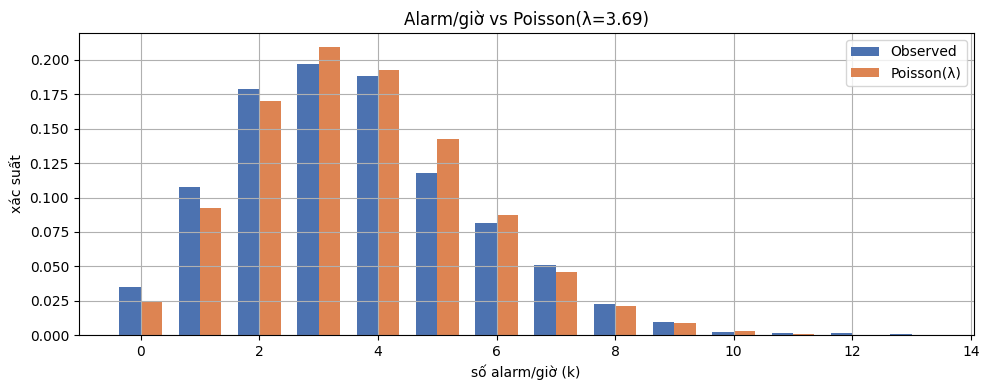

In [20]:
# So sánh trực quan: tần suất quan sát vs PMF Poisson(λ)
kmax = int(alarms.quantile(0.995)) + 1
ks = np.arange(0, kmax + 1)
obs = alarms.value_counts(normalize=True).reindex(ks, fill_value=0).values
poi = stats.poisson.pmf(ks, lam)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ks - 0.18, obs, width=0.36, label="Observed", color="#4C72B0")
ax.bar(ks + 0.18, poi, width=0.36, label="Poisson(λ)", color="#DD8452")
ax.set_xlabel("số alarm/giờ (k)"); ax.set_ylabel("xác suất"); ax.legend()
ax.set_title(f"Alarm/giờ vs Poisson(λ={lam:.2f})")
plt.tight_layout(); plt.show()

In [21]:
# Khung giờ / region có alarm bất thường (đuôi phải lệch khỏi Poisson)
region_alarm = df_clean.groupby("region")["alarms_per_hour"].agg(["mean", "max"]).sort_values("mean", ascending=False)
region_alarm

,mean,max
region,,
Region_A,5.086,33
Region_D,3.313,31
Region_B,3.217,32
Region_C,3.146,26


### 📝 Nhận xét Phần E (điền của học viên)
- Phần thân phân phối bám khá sát Poisson, nhưng **đuôi phải nặng hơn** (do các spike vận hành) → gợi ý overdispersion.
- Region_A có mean alarm cao hơn → cần chú ý.


## 9. Bước 5 (bài tập có hướng dẫn) – Tổng hợp theo ngày & theo tuần

Quan sát: tổng hợp cao hơn thường làm phân phối mượt hơn nhưng có thể **che mất spike**.


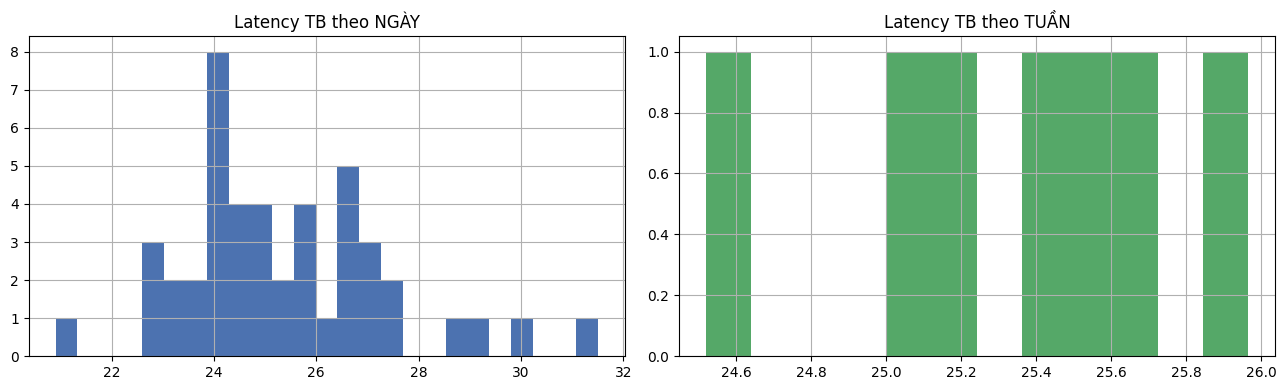

Std theo ngày: 2.043 | Std theo tuần: 0.470


In [22]:
daily = df_clean.groupby("date")["latency_ms"].mean()
weekly = df_clean.assign(week=df_clean["date"].dt.isocalendar().week).groupby("week")["latency_ms"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
daily.hist(bins=25, ax=axes[0], color="#4C72B0"); axes[0].set_title("Latency TB theo NGÀY")
weekly.hist(bins=12, ax=axes[1], color="#55A868"); axes[1].set_title("Latency TB theo TUẦN")
plt.tight_layout(); plt.show()

print(f"Std theo ngày: {daily.std():.3f} | Std theo tuần: {weekly.std():.3f}")

## 10. Phần F – Kết luận vận hành

Yêu cầu: xác định 3–5 khu vực cần kiểm tra + lý do + đề xuất bước tiếp theo.


In [23]:
# Bảng tổng hợp hỗ trợ kết luận: theo region
summary = df_clean.groupby("region").agg(
    latency_p95=("latency_ms", lambda s: s.quantile(0.95)),
    drop_mean=("drop_rate_pct", "mean"),
    alarm_mean=("alarms_per_hour", "mean"),
    cssr_median=("cssr_pct", "median"),
).sort_values("latency_p95", ascending=False)
summary

,latency_p95,drop_mean,alarm_mean,cssr_median
region,,,,
Region_A,65.542,1.413,5.086,98.998
Region_D,39.493,0.712,3.313,99.050
Region_B,38.823,0.638,3.217,99.019
Region_C,38.484,0.661,3.146,98.988


### 📝 Kết luận vận hành (mẫu – học viên hoàn thiện)

Ví dụ cấu trúc (slide 17):
> **Region_A** có latency P95 cao và nhiều outlier theo giờ cao điểm, kèm alarm/giờ trung bình cao hơn các region khác. Cần kiểm tra thêm tải PRB và alarm tương ứng trong cùng khung giờ.

**3–5 khu vực cần kiểm tra:**
1. Region_A – latency P95 & alarm cao → ...
2. ...

**Đề xuất bước tiếp theo:** đối chiếu spike latency với log alarm theo site/giờ; kiểm tra tải PRB giờ cao điểm; (Buổi 2) đặt giả thuyết & kiểm định sự khác biệt giữa Region_A và phần còn lại.


In [24]:
# (tùy chọn) export bảng phục vụ báo cáo
# summary.to_csv("kpi_region_summary.csv")
# profile.to_csv("kpi_profile_overall.csv")
print("Notebook hoàn tất — chạy được từ đầu đến cuối.")

Notebook hoàn tất — chạy được từ đầu đến cuối.
